In [54]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

from utils.post_training import *
from utils.statistics import *
from utils.plotting import *
from utils.encodings import *
from utils.haar_noising_script import apply_haar_scrambling

import numpy as np
import h5py
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scipy.linalg

import pennylane as qml

/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model


In [55]:
QG_channel = 1
filename = f"data/QG{QG_channel}_64x64_1k"
# filename = f"data/QG{QG_channel}_16x16_1k"
with h5py.File(filename, "r") as f:
    data_X = np.array(f["X"])

# If the dataset includes channels, select the requested QG channel (1-indexed)
if data_X.ndim == 4:
    data_X = data_X[..., QG_channel - 1]

# Preprocess like other notebooks: log, normalize, map to [-1, 1]
data_X = data_X.astype(np.float32)
data_X = np.log1p(data_X)
data_X = data_X / data_X.max()
data_X = 2.0 * data_X - 1.0

print("Dataset shape:", data_X.shape, "min:", data_X.min(), "max:", data_X.max())


Dataset shape: (1000, 64, 64) min: -1.0 max: 1.0


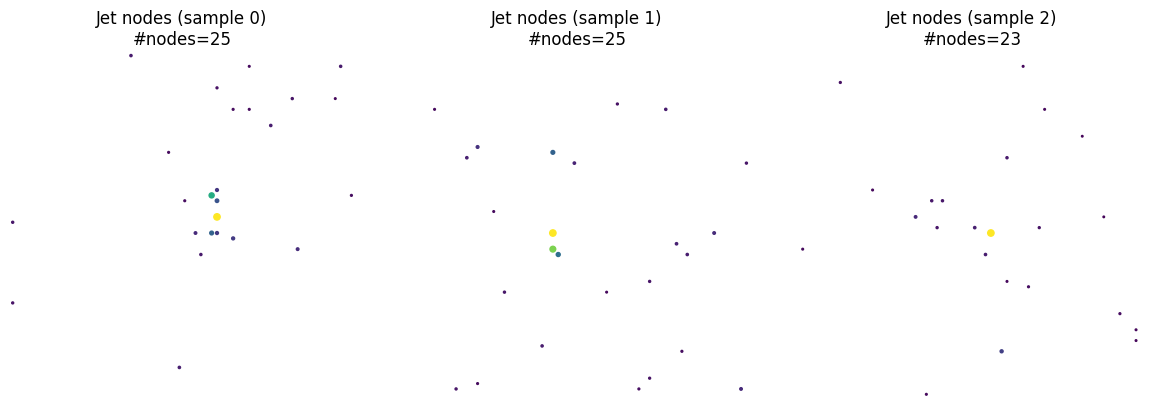

In [56]:
# --- Visualize jet-structure learning target (energy-based nodes only) ---

def _to_single_channel(sample, channel=0):
    if sample.ndim == 3:
        return sample[..., channel]
    return sample

def _normalize_for_graph(img):
    img = img.astype(np.float32)
    if img.min() < 0:
        img = (img - img.min()) / (img.max() - img.min() + 1e-12)
    elif img.max() > 1.0:
        img = img / (img.max() + 1e-12)
    return img

def extract_energy_nodes(img, energy_quantile=0.995):
    """
    Keep the minimal set of highest-intensity pixels whose cumulative
    energy reaches the given quantile. Each pixel is its own node.
    """
    img_n = _normalize_for_graph(img)
    flat = img_n.flatten()
    total = flat.sum()

    if total <= 0:
        return img_n, np.empty((0, 2)), np.array([])

    order = np.argsort(flat)[::-1]  # descending by intensity
    cumsum = np.cumsum(flat[order])
    cutoff_idx = np.searchsorted(cumsum, energy_quantile * total)
    keep_idx = order[:cutoff_idx + 1]

    coords = np.column_stack(np.unravel_index(keep_idx, img_n.shape))
    intens = flat[keep_idx]

    return img_n, coords, intens

def plot_energy_nodes(ax, img, energy_quantile=0.995, cmap="viridis"):
    img_n, coords, intens = extract_energy_nodes(img, energy_quantile=energy_quantile)
    H, W = img_n.shape

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.axis("off")

    if intens.size == 0:
        return 0

    sizes = 20.0 * (intens / (intens.max() + 1e-12) + 0.05)
    ax.scatter(coords[:, 1], coords[:, 0], s=sizes, c=intens, cmap=cmap, vmin=0, vmax=intens.max())
    return len(intens)

num_samples_to_plot = 3
sample_indices = list(range(num_samples_to_plot))

fig, axes = plt.subplots(1, num_samples_to_plot, figsize=(4 * num_samples_to_plot, 4))
if num_samples_to_plot == 1:
    axes = [axes]

for i, idx in enumerate(sample_indices):
    sample = _to_single_channel(data_X[idx], channel=0)
    n_nodes = plot_energy_nodes(axes[i], sample, energy_quantile=0.995)
    axes[i].set_title(f"Jet nodes (sample {idx})\n#nodes={n_nodes}")

plt.tight_layout()
plt.show()


In [57]:
# --- (1) Fixed-length node set with mask (energy-based foreground only) ---
energy_quantile = 0.995
K_max = 256  # max nodes per jet; tune as needed
num_samples_for_nodes = min(1000, data_X.shape[0])
log_eps = 1e-6

def nodes_to_fixed(coords, intens, H, W, K_max):
    """Convert variable-length nodes to fixed-length (K_max, 3) with mask."""
    if intens.size == 0:
        return np.zeros((K_max, 3), dtype=np.float32), np.zeros((K_max,), dtype=np.float32), 0

    order = np.argsort(intens)[::-1]
    coords = coords[order]
    intens = intens[order]

    # Normalize coordinates to [-1, 1]
    xs = coords[:, 1] / (W - 1 + 1e-12)
    ys = coords[:, 0] / (H - 1 + 1e-12)
    xs = 2.0 * xs - 1.0
    ys = 2.0 * ys - 1.0

    # Log-intensity target (<= 0)
    intens_log = np.log(intens + log_eps)

    feats = np.stack([xs, ys, intens_log], axis=1).astype(np.float32)
    n = min(len(feats), K_max)

    out = np.zeros((K_max, 3), dtype=np.float32)
    mask = np.zeros((K_max,), dtype=np.float32)
    out[:n] = feats[:n]
    mask[:n] = 1.0
    return out, mask, n

nodes_all = np.zeros((num_samples_for_nodes, K_max, 3), dtype=np.float32)
mask_all = np.zeros((num_samples_for_nodes, K_max), dtype=np.float32)
lengths = np.zeros((num_samples_for_nodes,), dtype=np.int32)

for i in range(num_samples_for_nodes):
    sample = _to_single_channel(data_X[i], channel=0)
    img_n, coords, intens = extract_energy_nodes(sample, energy_quantile=energy_quantile)
    H, W = img_n.shape
    nodes, mask, n = nodes_to_fixed(coords, intens, H, W, K_max)
    nodes_all[i] = nodes
    mask_all[i] = mask
    lengths[i] = n

print("Nodes tensor:", nodes_all.shape, "Mask tensor:", mask_all.shape)
print("Avg #nodes:", lengths.mean(), "Max #nodes:", lengths.max())

# torch tensors for modeling
nodes_t = torch.tensor(nodes_all, dtype=torch.float32)
mask_t = torch.tensor(mask_all, dtype=torch.float32)
counts_t = torch.tensor(lengths / K_max, dtype=torch.float32).unsqueeze(1)


Nodes tensor: (1000, 256, 3) Mask tensor: (1000, 256)
Avg #nodes: 22.761 Max #nodes: 59


In [60]:
# --- (2) Foreground-only flow matching model (count-conditioned + constrained outputs) ---
device = "mps" if torch.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

features_per_node = 3
dim = K_max * features_per_node

# Flatten nodes to a fixed vector per sample
x0 = nodes_t.view(nodes_t.shape[0], -1).to(device)
mask_flat = mask_t.view(mask_t.shape[0], -1).to(device)  # (B, K_max)
mask_feat = mask_flat.repeat_interleave(features_per_node, dim=1)
counts_t = counts_t.to(device)

def timestep_embedding(t, dim=64):
    """Sinusoidal time embedding. t: (B,1) in [0,1]."""
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half, device=t.device) / (half - 1))
    args = t * freqs
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return emb

def count_embedding(c, dim=32):
    """Sinusoidal embedding for count (normalized to [0,1])."""
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half, device=c.device) / (half - 1))
    args = c * freqs
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return emb

class SimpleFlowMLP(nn.Module):
    def __init__(self, dim, nodes, hidden=512, time_dim=64, count_dim=32):
        super().__init__()
        self.time_dim = time_dim
        self.count_dim = count_dim
        self.backbone = nn.Sequential(
            nn.Linear(dim + time_dim + count_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
        )
        self.v_head = nn.Linear(hidden, dim)
        self.mask_head = nn.Linear(hidden, nodes)

    def forward(self, x, t, c):
        t_emb = timestep_embedding(t, self.time_dim)
        c_emb = count_embedding(c, self.count_dim)
        h = torch.cat([x, t_emb, c_emb], dim=-1)
        h = self.backbone(h)
        v = self.v_head(h)
        mask_logits = self.mask_head(h)
        return v, mask_logits

model = SimpleFlowMLP(dim=dim, nodes=K_max, hidden=512, time_dim=64, count_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Simple rectified-flow training loop (masked)
batch_size = 32
num_steps = 200
mask_weight = 1.0

for step in range(num_steps):
    idx = torch.randint(0, x0.shape[0], (batch_size,), device=device)
    x = x0[idx]
    m_feat = mask_feat[idx]
    m = mask_flat[idx]
    c = counts_t[idx]
    t = torch.rand(batch_size, 1, device=device)

    x1 = torch.randn_like(x)
    xt = (1 - t) * x + t * x1
    v_target = x1 - x
    v_pred, mask_logits = model(xt, t, c)

    # Masked MSE for flow (ignore padded nodes)
    loss_flow = ((v_pred - v_target) ** 2 * m_feat).sum() / (m_feat.sum() + 1e-12)
    loss_mask = F.binary_cross_entropy_with_logits(mask_logits, m)
    loss = loss_flow + mask_weight * loss_mask

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
        print(f"Step {step}: loss={loss.item():.6f} (flow={loss_flow.item():.6f}, mask={loss_mask.item():.6f})")


Using device: mps
Step 0: loss=4.310688 (flow=3.618434, mask=0.692254)
Step 10: loss=4.229481 (flow=3.545870, mask=0.683611)
Step 20: loss=4.089845 (flow=3.424958, mask=0.664888)
Step 30: loss=3.462180 (flow=2.837762, mask=0.624418)
Step 40: loss=3.434243 (flow=2.904731, mask=0.529512)
Step 50: loss=2.533835 (flow=2.153883, mask=0.379952)
Step 60: loss=1.798864 (flow=1.572060, mask=0.226804)
Step 70: loss=1.555979 (flow=1.398424, mask=0.157555)
Step 80: loss=1.531917 (flow=1.390741, mask=0.141177)
Step 90: loss=1.590812 (flow=1.490451, mask=0.100361)
Step 100: loss=1.450799 (flow=1.348335, mask=0.102464)
Step 110: loss=1.468985 (flow=1.373170, mask=0.095815)
Step 120: loss=1.654765 (flow=1.574921, mask=0.079843)
Step 130: loss=1.494578 (flow=1.410864, mask=0.083714)
Step 140: loss=1.433320 (flow=1.361107, mask=0.072213)
Step 150: loss=1.466617 (flow=1.384773, mask=0.081844)
Step 160: loss=1.418913 (flow=1.349548, mask=0.069366)
Step 170: loss=1.446506 (flow=1.366173, mask=0.080332)
Ste

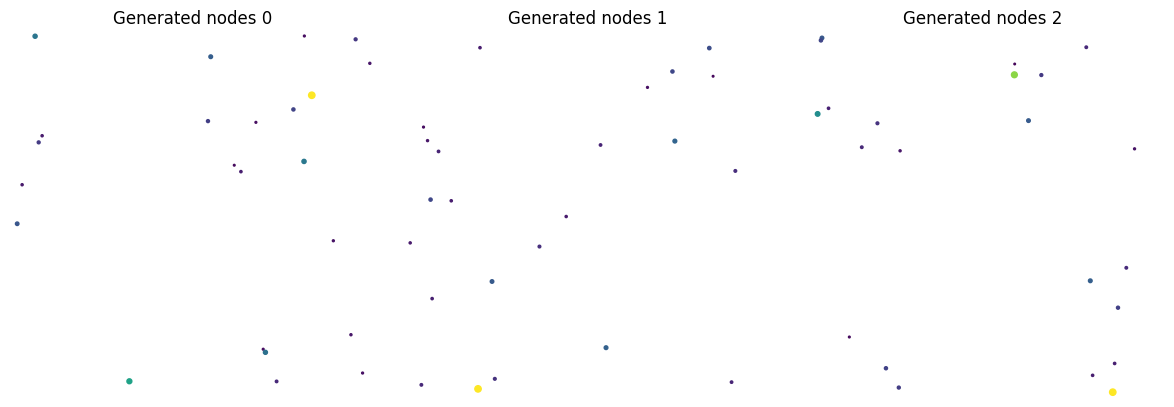

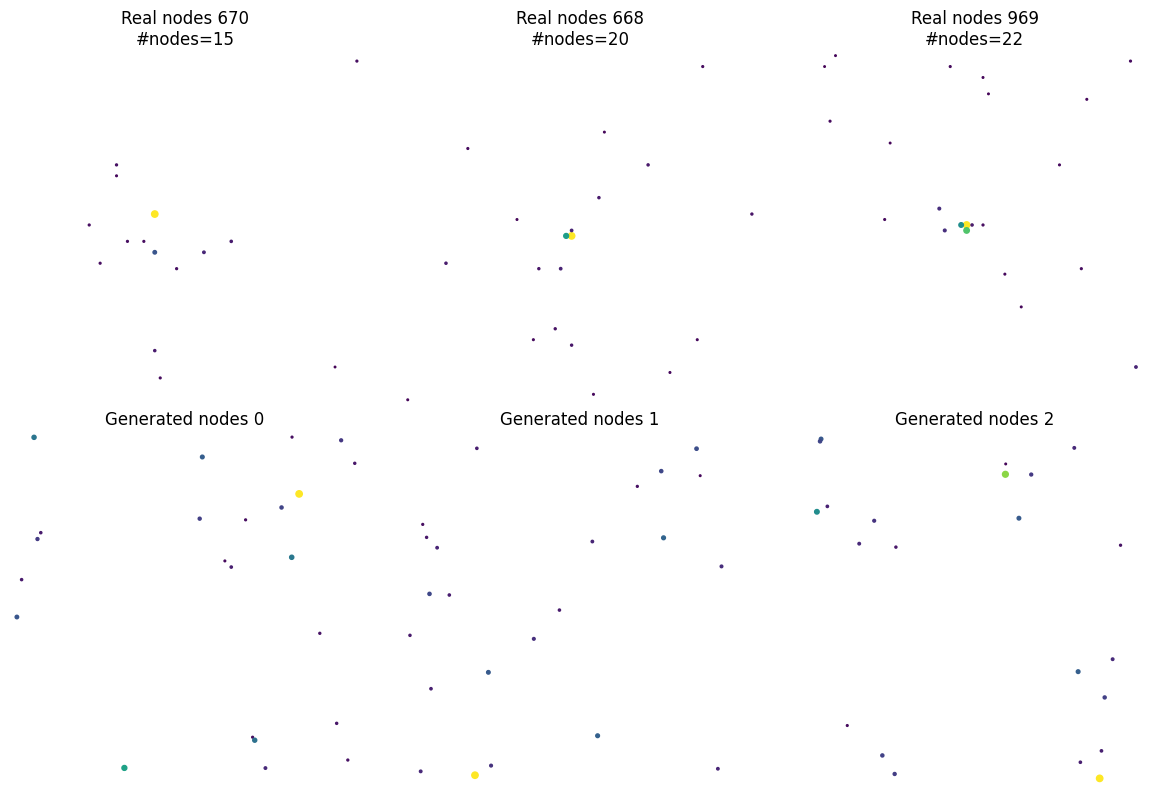

In [61]:
# --- Eval: sample from trained flow and visualize generated nodes ---
def apply_constraints(x_flat):
    nodes = x_flat.view(-1, K_max, 3)
    nodes_xy = torch.tanh(nodes[..., 0:2])
    logI = -F.softplus(nodes[..., 2:3])
    nodes = torch.cat([nodes_xy, logI], dim=-1)
    return nodes.view(-1, K_max * 3)

def flow_sample(model, num_samples, steps=50, device="cpu", counts=None):
    """Simple Euler sampler for rectified flow."""
    model.eval()
    with torch.no_grad():
        if counts is None:
            idx = torch.randint(0, counts_t.shape[0], (num_samples,), device=device)
            counts = counts_t[idx]
        else:
            counts = counts.to(device).view(num_samples, 1)

        x = torch.randn(num_samples, dim, device=device)
        dt = 1.0 / steps
        for s in range(steps):
            t = torch.full((num_samples, 1), s / steps, device=device)
            v, _ = model(x, t, counts)
            x = x + v * dt
        x = apply_constraints(x)
    return x, counts

def predict_mask(model, x_flat, counts):
    model.eval()
    with torch.no_grad():
        t0 = torch.zeros(x_flat.shape[0], 1, device=x_flat.device)
        _, mask_logits = model(x_flat, t0, counts)
        mask = torch.sigmoid(mask_logits)
    return mask

def unflatten_nodes(x_flat, K_max):
    return x_flat.view(-1, K_max, 3)

def plot_generated_nodes(ax, nodes, mask=None, cmap="viridis"):
    # nodes: (K,3) with x,y in [-1,1], log-intensity in (−inf, 0]
    xs = nodes[:, 0]
    ys = nodes[:, 1]
    intens = torch.exp(nodes[:, 2])

    if mask is not None:
        keep = mask > 0.5
        xs = xs[keep]
        ys = ys[keep]
        intens = intens[keep]

    if intens.numel() == 0:
        ax.axis("off")
        ax.set_title("(empty)")
        return

    # map to image coordinates
    xs = (xs + 1.0) * 0.5 * (data_X.shape[2] - 1)
    ys = (ys + 1.0) * 0.5 * (data_X.shape[1] - 1)

    sizes = 20.0 * (intens / (intens.max() + 1e-12) + 0.05)
    ax.scatter(xs.cpu().numpy(), ys.cpu().numpy(), s=sizes.cpu().numpy(), c=intens.cpu().numpy(),
               cmap=cmap, vmin=0, vmax=float(intens.max().cpu()))
    ax.set_xlim(-0.5, data_X.shape[2] - 0.5)
    ax.set_ylim(data_X.shape[1] - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.axis("off")

num_gen = 3
gen_flat, gen_counts = flow_sample(model, num_gen, steps=50, device=device)
gen_mask = predict_mask(model, gen_flat, gen_counts)
gen_nodes = unflatten_nodes(gen_flat, K_max)

fig, axes = plt.subplots(1, num_gen, figsize=(4 * num_gen, 4))
if num_gen == 1:
    axes = [axes]

for i in range(num_gen):
    plot_generated_nodes(axes[i], gen_nodes[i], mask=gen_mask[i])
    axes[i].set_title(f"Generated nodes {i}")

plt.tight_layout()
plt.show()

# --- Plot a few original node graphs alongside ---
num_real = num_gen
real_idx = np.random.choice(data_X.shape[0], size=num_real, replace=False)

fig, axes = plt.subplots(2, num_real, figsize=(4 * num_real, 8))
if num_real == 1:
    axes = np.array([axes]).reshape(2, 1)

for i in range(num_real):
    # real
    sample = _to_single_channel(data_X[real_idx[i]], channel=0)
    n_nodes = plot_energy_nodes(axes[0, i], sample, energy_quantile=energy_quantile)
    axes[0, i].set_title(f"Real nodes {real_idx[i]}\n#nodes={n_nodes}")

    # generated
    plot_generated_nodes(axes[1, i], gen_nodes[i], mask=gen_mask[i])
    axes[1, i].set_title(f"Generated nodes {i}")

plt.tight_layout()
plt.show()


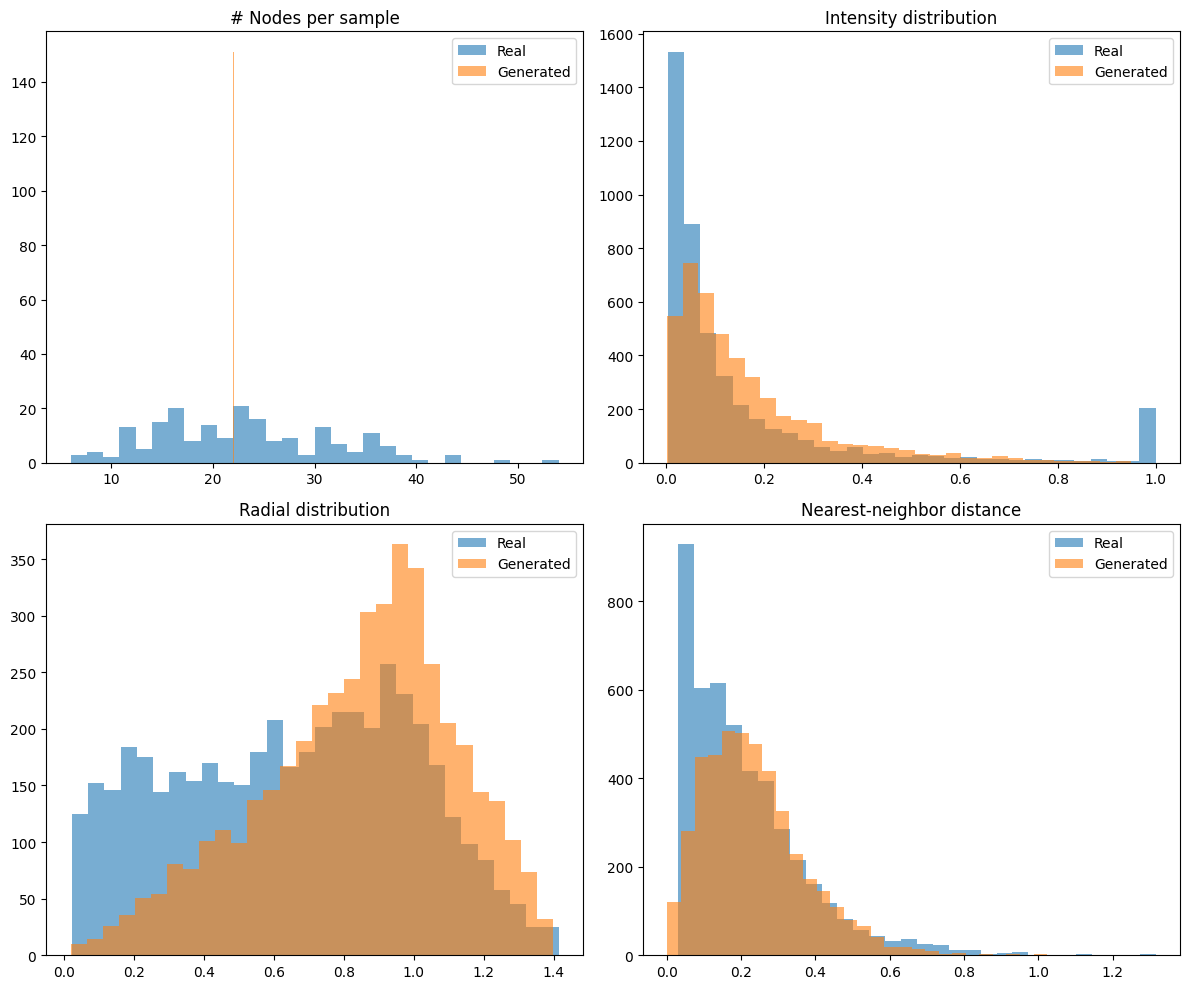

In [62]:
# --- Foreground-only quantitative evals (real vs generated) ---
import numpy as np

def nodes_from_real_sample(idx, energy_quantile=0.995):
    sample = _to_single_channel(data_X[idx], channel=0)
    img_n, coords, intens = extract_energy_nodes(sample, energy_quantile=energy_quantile)
    # coords: (N,2) in (row, col)
    H, W = img_n.shape
    if intens.size == 0:
        return np.empty((0, 3))
    xs = coords[:, 1] / (W - 1 + 1e-12)
    ys = coords[:, 0] / (H - 1 + 1e-12)
    xs = 2.0 * xs - 1.0
    ys = 2.0 * ys - 1.0
    return np.stack([xs, ys, intens], axis=1)

def nodes_from_generated(gen_nodes_i, gen_mask_i):
    # gen_nodes_i: (K,3) in [-1,1] with log-intensity
    nodes = gen_nodes_i.detach().cpu().numpy()
    mask = (gen_mask_i.detach().cpu().numpy() > 0.5)
    nodes = nodes[mask]
    if nodes.size == 0:
        return nodes
    nodes[:, 2] = np.exp(nodes[:, 2])
    return nodes

def radial_dist(nodes):
    if nodes.shape[0] == 0:
        return np.array([])
    xs, ys = nodes[:, 0], nodes[:, 1]
    return np.sqrt(xs**2 + ys**2)

def nearest_neighbor_dist(nodes):
    if nodes.shape[0] < 2:
        return np.array([])
    pts = nodes[:, :2]
    dists = []
    for i in range(len(pts)):
        diff = pts - pts[i]
        dist = np.sqrt((diff**2).sum(axis=1))
        dist[i] = np.inf
        dists.append(dist.min())
    return np.array(dists)

# Build evaluation sets
num_eval = min(200, data_X.shape[0])
real_idx = np.random.choice(data_X.shape[0], size=num_eval, replace=False)
real_nodes_list = [nodes_from_real_sample(i, energy_quantile=energy_quantile) for i in real_idx]

gen_flat, gen_counts = flow_sample(model, num_eval, steps=50, device=device)
gen_mask = predict_mask(model, gen_flat, gen_counts)
gen_nodes = unflatten_nodes(gen_flat, K_max)
gen_nodes_list = [nodes_from_generated(gen_nodes[i], gen_mask[i]) for i in range(num_eval)]

# 1) Node count distribution
real_counts = np.array([n.shape[0] for n in real_nodes_list])
gen_counts = np.array([n.shape[0] for n in gen_nodes_list])

# 2) Intensity distribution
real_intens = np.concatenate([n[:, 2] for n in real_nodes_list if n.shape[0] > 0])
gen_intens = np.concatenate([n[:, 2] for n in gen_nodes_list if n.shape[0] > 0])

# 3) Radial distribution
real_r = np.concatenate([radial_dist(n) for n in real_nodes_list if n.shape[0] > 0])
gen_r = np.concatenate([radial_dist(n) for n in gen_nodes_list if n.shape[0] > 0])

# 4) Nearest-neighbor distances
real_nn = np.concatenate([nearest_neighbor_dist(n) for n in real_nodes_list if n.shape[0] > 1])
gen_nn = np.concatenate([nearest_neighbor_dist(n) for n in gen_nodes_list if n.shape[0] > 1])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(real_counts, bins=30, alpha=0.6, label="Real")
axes[0, 0].hist(gen_counts, bins=30, alpha=0.6, label="Generated")
axes[0, 0].set_title("# Nodes per sample")
axes[0, 0].legend()

axes[0, 1].hist(real_intens, bins=30, alpha=0.6, label="Real")
axes[0, 1].hist(gen_intens, bins=30, alpha=0.6, label="Generated")
axes[0, 1].set_title("Intensity distribution")
axes[0, 1].legend()

axes[1, 0].hist(real_r, bins=30, alpha=0.6, label="Real")
axes[1, 0].hist(gen_r, bins=30, alpha=0.6, label="Generated")
axes[1, 0].set_title("Radial distribution")
axes[1, 0].legend()

axes[1, 1].hist(real_nn, bins=30, alpha=0.6, label="Real")
axes[1, 1].hist(gen_nn, bins=30, alpha=0.6, label="Generated")
axes[1, 1].set_title("Nearest-neighbor distance")
axes[1, 1].legend()

plt.tight_layout()
plt.show()
